# 04 — Agent Simulation

**Section 3 implementation — Approach A (Object LLM + Differentiated Python)**

Pipeline:
1. Gemini extracts cues from every email → cached to `data/cue_cache/`
2. N synthetic agents are generated with random demographic/psychological traits
3. Each agent processes every email at 5 points across their workday
4. Per-cue Flawed Perception Level governs stochastic cue-missing
5. Results analysed: click rate by source, hour, fatigue, and agent traits

## 0 — Setup

In [2]:
import sys, os
from pathlib import Path

# Make sure the repo root is on the path so `src` is importable
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv(ROOT / '.env')

from src.agent import Agent
from src.cue_extractor import CueExtractor
from src.decision_loop import simulate_email
from src.simulation import run_simulation, save_results, click_rate_summary

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print('All imports OK')
print(f'Root: {ROOT}')

ImportError: cannot import name 'genai' from 'google' (unknown location)

## 1 — Spot-check: single agent, single email

In [14]:
# Create one agent and inspect their traits
agent = Agent.random_agent('demo_agent', seed=7)

print('=== Agent traits ===')
print(f'  age={agent.age:.1f}, gender={int(agent.gender)}, '
      f'education={agent.education_level:.1f}, tenure={agent.tenure:.1f}y')
print(f'  job_type={int(agent.job_type)} (1=desk), job_complexity={agent.job_complexity:.1f}')
print(f'  suspicion_threshold={agent.suspicion_threshold}, '
      f'max_cues_processed={agent.max_cues_processed}')
print()

print('=== Internal state at 8am vs 4pm ===')
for hour in [8.0, 16.0]:
    agent.advance_workday(hour)
    tf = agent.compute_total_fatigue()
    jp = agent.compute_job_performance()
    fpl = agent.compute_flawed_perception_level()
    print(f'  {int(hour):02d}:00 → fatigue={tf:.2f}, final_jp={jp:.2f}, fpl={fpl:.3f}')

=== Agent traits ===
  age=34.3, gender=0, education=2.6, tenure=1.4y
  job_type=0 (1=desk), job_complexity=2.5
  suspicion_threshold=6, max_cues_processed=11

=== Internal state at 8am vs 4pm ===
  08:00 → fatigue=4.08, final_jp=1.86, fpl=0.206
  16:00 → fatigue=4.08, final_jp=1.69, fpl=0.223


In [15]:
# Decision loop demo — same email, same agent, at 8am vs 4pm
sample_cues = ['urgency', 'generic_greeting', 'personal_info', 'suspicious_link', 'threats']

print('=== Decision loop demo ===')
for hour in [8.0, 12.0, 16.0]:
    agent.advance_workday(hour)
    result = simulate_email(agent, sample_cues)
    print(f'  {int(hour):02d}:00 fpl={result["fpl"]:.3f} → '
          f'{result["decision"].upper():8s} '
          f'(perceived {result["suspicion_counter"]}/{len(sample_cues)} cues: '
          f'{result["cues_perceived"]})')

=== Decision loop demo ===
  08:00 fpl=0.206 → CLICKED  (perceived 4/5 cues: ['generic_greeting', 'suspicious_link', 'personal_info', 'threats'])
  12:00 fpl=0.214 → CLICKED  (perceived 4/5 cues: ['threats', 'generic_greeting', 'urgency', 'personal_info'])
  16:00 fpl=0.223 → CLICKED  (perceived 3/5 cues: ['generic_greeting', 'personal_info', 'threats'])


## 2 — Run the full simulation

> **First run:** Step 1 calls Gemini for all 250 emails and caches results in `data/cue_cache/`.  
> **Subsequent runs:** Step 1 is instant (all cached).

In [16]:
results_path = ROOT / 'data' / 'simulation_results.csv'

# Set RERUN = True to re-simulate even if results already exist
RERUN = False

if not results_path.exists() or RERUN:
    df = run_simulation(
        emails_csv=str(ROOT / 'data' / 'processed' / 'master_emails.csv'),
        n_agents=30,
        workday_hours=[8.0, 10.0, 12.0, 14.0, 16.0],
        seed=42,
        cache_dir=str(ROOT / 'data' / 'cue_cache'),
    )
    save_results(df, str(results_path))
else:
    df = pd.read_csv(results_path)
    print(f'Loaded existing results: {len(df):,} rows')

df.head()

Loaded existing results: 37,500 rows


,step_id,agent_id,email_id,source,actual_class,workday_hour,time_of_day,suspicion_threshold,max_cues_processed,age,education_level,job_complexity,cues_extracted,decision,suspicion_counter,cues_scanned,cues_perceived,total_fatigue,final_jp,fpl
0,0,agent_000,1,spamassassin_ham,0,8.0,8am,3,10,30.7,2.6,5.0,0,clicked,0,0,[],5.0,1.161,0.355
1,1,agent_000,2,spamassassin_ham,0,8.0,8am,3,10,30.7,2.6,5.0,1,clicked,1,1,['suspicious_link'],5.0,1.161,0.355
2,2,agent_000,3,spamassassin_ham,0,8.0,8am,3,10,30.7,2.6,5.0,0,clicked,0,0,[],5.0,1.161,0.355
3,3,agent_000,4,spamassassin_ham,0,8.0,8am,3,10,30.7,2.6,5.0,1,clicked,0,1,[],5.0,1.161,0.355
4,4,agent_000,5,spamassassin_ham,0,8.0,8am,3,10,30.7,2.6,5.0,1,clicked,1,1,['spelling_grammar'],5.0,1.161,0.355


## 3 — Validate cue extraction

Cues extracted per email by source:
                  mean  median  min  max  count
source                                         
hybrid_vtriad     2.34     2.0    2    4     50
phishbowl         0.78     0.0    0    5     50
plain_llm         0.42     0.0    0    2     50
spamassassin_ham  0.34     0.0    0    2    100


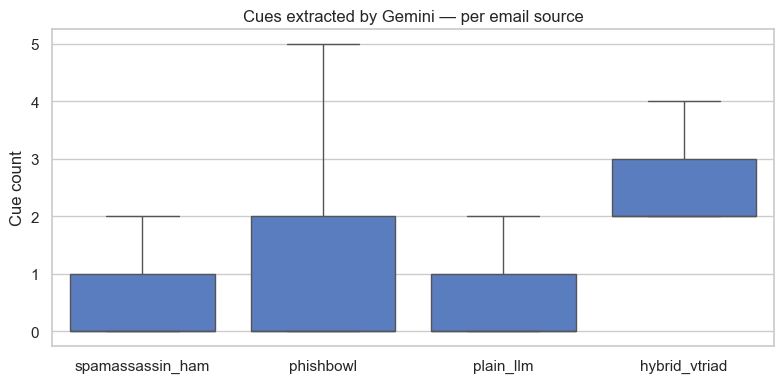

In [17]:
# How many cues did Gemini find per email source?
cue_stats = (
    df[['email_id', 'source', 'actual_class', 'cues_extracted']]
    .drop_duplicates('email_id')
    .groupby('source')['cues_extracted']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .round(2)
)
print('Cues extracted per email by source:')
print(cue_stats)

fig, ax = plt.subplots(figsize=(8, 4))
per_email = df[['email_id', 'source', 'cues_extracted']].drop_duplicates('email_id')
sns.boxplot(data=per_email, x='source', y='cues_extracted', ax=ax)
ax.set_title('Cues extracted by Gemini — per email source')
ax.set_xlabel('')
ax.set_ylabel('Cue count')
plt.tight_layout()
plt.show()

## 4 — Click rates: phishing emails

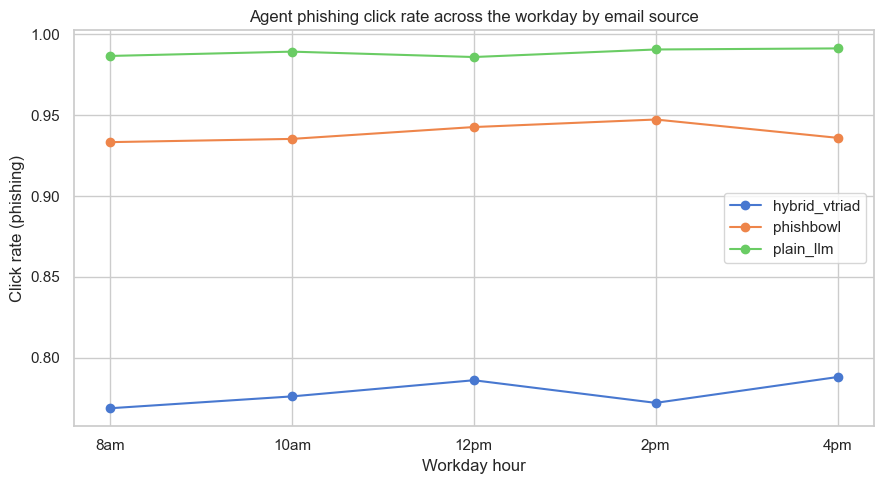

In [18]:
# Click rate = fraction of phishing emails where agent chose 'clicked' (vulnerability)
phishing_df = df[df['actual_class'] == 1].copy()
phishing_df['clicked'] = (phishing_df['decision'] == 'clicked').astype(int)

by_source_hour = (
    phishing_df.groupby(['source', 'workday_hour'])['clicked']
    .mean()
    .reset_index()
    .rename(columns={'clicked': 'click_rate'})
)

fig, ax = plt.subplots(figsize=(9, 5))
for source, grp in by_source_hour.groupby('source'):
    ax.plot(grp['workday_hour'], grp['click_rate'], marker='o', label=source)
ax.set_xlabel('Workday hour')
ax.set_ylabel('Click rate (phishing)')
ax.set_title('Agent phishing click rate across the workday by email source')
ax.legend()
ax.set_xticks([8, 10, 12, 14, 16])
ax.set_xticklabels(['8am', '10am', '12pm', '2pm', '4pm'])
plt.tight_layout()
plt.show()

In [19]:
# False positive rate: how often do agents 'report' benign emails?
benign_df = df[df['actual_class'] == 0].copy()
benign_df['reported'] = (benign_df['decision'] == 'reported').astype(int)

fpr_by_hour = (
    benign_df.groupby('workday_hour')['reported']
    .mean()
    .reset_index()
    .rename(columns={'reported': 'false_positive_rate'})
)
print('False positive rate (benign emails incorrectly reported as phishing):')
print(fpr_by_hour.to_string(index=False))

False positive rate (benign emails incorrectly reported as phishing):
 workday_hour  false_positive_rate
          8.0             0.008333
         10.0             0.010000
         12.0             0.009000
         14.0             0.007667
         16.0             0.010000


## 5 — Fatigue effect on click rate

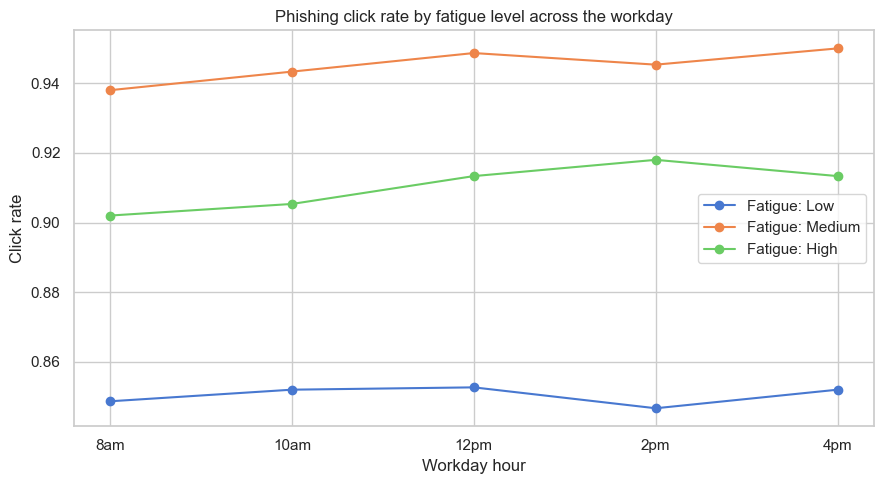

In [20]:
# Bin agents into low/medium/high fatigue quartiles
phishing_df['fatigue_bin'] = pd.qcut(
    phishing_df['total_fatigue'], q=3, labels=['Low', 'Medium', 'High']
)

fatigue_click = (
    phishing_df.groupby(['fatigue_bin', 'workday_hour'])['clicked']
    .mean()
    .reset_index()
    .rename(columns={'clicked': 'click_rate'})
)

fig, ax = plt.subplots(figsize=(9, 5))
for fb, grp in fatigue_click.groupby('fatigue_bin', observed=True):
    ax.plot(grp['workday_hour'], grp['click_rate'], marker='o', label=f'Fatigue: {fb}')
ax.set_xlabel('Workday hour')
ax.set_ylabel('Click rate')
ax.set_title('Phishing click rate by fatigue level across the workday')
ax.legend()
ax.set_xticks([8, 10, 12, 14, 16])
ax.set_xticklabels(['8am', '10am', '12pm', '2pm', '4pm'])
plt.tight_layout()
plt.show()

## 6 — Agent trait correlations

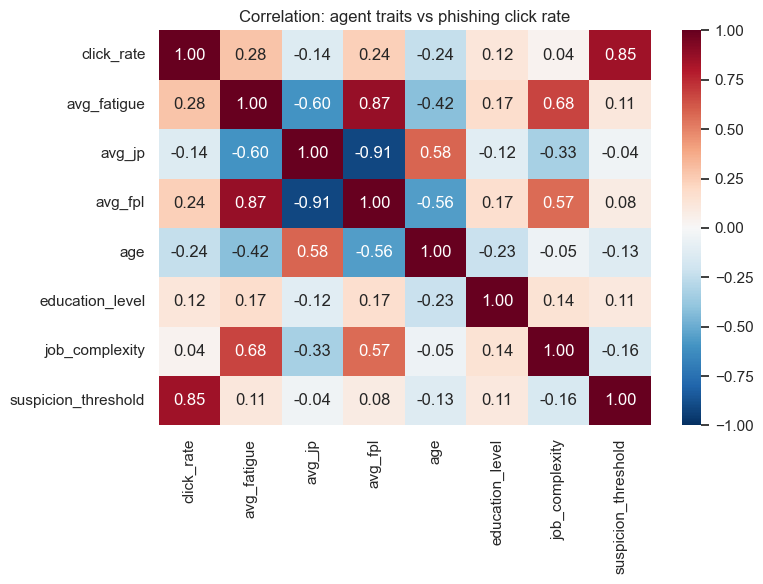

In [21]:
# Per-agent click rate on phishing emails (averaged across all hours and emails)
agent_summary = (
    phishing_df.groupby('agent_id')
    .agg(
        click_rate=('clicked', 'mean'),
        avg_fatigue=('total_fatigue', 'mean'),
        avg_jp=('final_jp', 'mean'),
        avg_fpl=('fpl', 'mean'),
        age=('age', 'first'),
        education_level=('education_level', 'first'),
        job_complexity=('job_complexity', 'first'),
        suspicion_threshold=('suspicion_threshold', 'first'),
    )
    .reset_index()
)

# Correlation heatmap
corr_cols = ['click_rate', 'avg_fatigue', 'avg_jp', 'avg_fpl',
             'age', 'education_level', 'job_complexity', 'suspicion_threshold']
corr = agent_summary[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: agent traits vs phishing click rate')
plt.tight_layout()
plt.show()

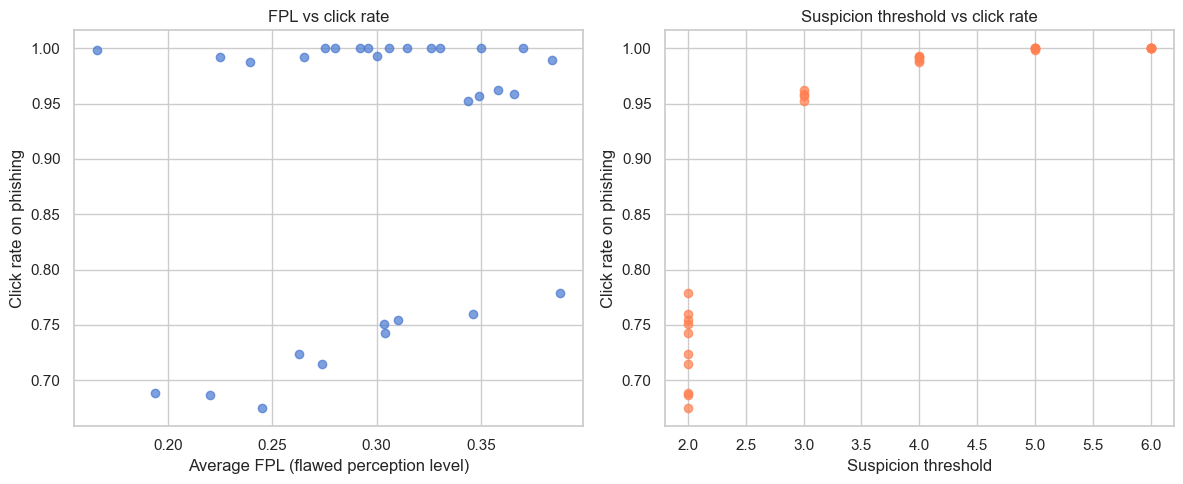

In [22]:
# Scatter: FPL vs click rate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(agent_summary['avg_fpl'], agent_summary['click_rate'], alpha=0.7)
axes[0].set_xlabel('Average FPL (flawed perception level)')
axes[0].set_ylabel('Click rate on phishing')
axes[0].set_title('FPL vs click rate')

axes[1].scatter(agent_summary['suspicion_threshold'], agent_summary['click_rate'],
                alpha=0.7, color='coral')
axes[1].set_xlabel('Suspicion threshold')
axes[1].set_ylabel('Click rate on phishing')
axes[1].set_title('Suspicion threshold vs click rate')

plt.tight_layout()
plt.show()

## 7 — Cue heatmap (which cues drive reporting)

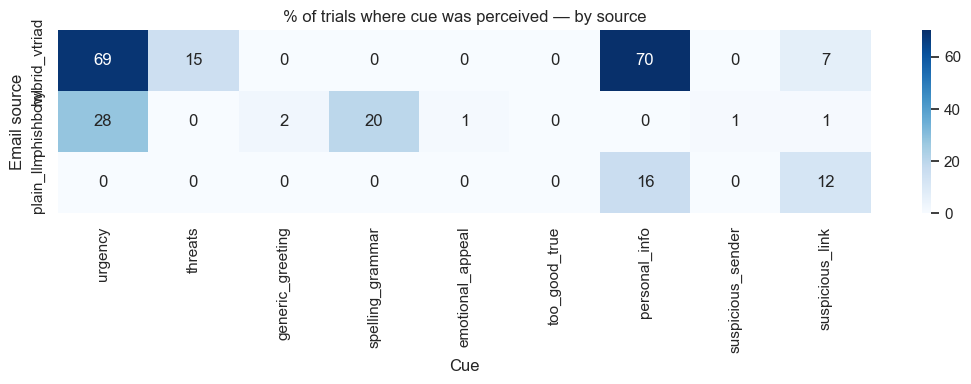

In [23]:
import ast

# Expand cues_perceived into one-hot columns
all_cues = [
    'urgency', 'threats', 'generic_greeting', 'spelling_grammar',
    'emotional_appeal', 'too_good_true', 'personal_info',
    'suspicious_sender', 'suspicious_link'
]

def parse_cues(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

phishing_df = phishing_df.copy()
phishing_df['cues_perceived'] = phishing_df['cues_perceived'].apply(parse_cues)

for cue in all_cues:
    phishing_df[f'perceived_{cue}'] = phishing_df['cues_perceived'].apply(
        lambda c: int(cue in c)
    )

# How often each cue is perceived per source
perceived_cols = [f'perceived_{c}' for c in all_cues]
cue_by_source = (
    phishing_df.groupby('source')[perceived_cols].mean() * 100
).round(1)
cue_by_source.columns = all_cues

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(cue_by_source, annot=True, fmt='.0f', cmap='Blues', ax=ax)
ax.set_title('% of trials where cue was perceived — by source')
ax.set_ylabel('Email source')
ax.set_xlabel('Cue')
plt.tight_layout()
plt.show()

## 8 — Summary table

In [24]:
summary = click_rate_summary(df)

# Phishing click rate (vulnerability) by source
print('Phishing click rate (vulnerability) — lower is better:')
print(summary[summary['actual_class'] == 1]
      .pivot(index='source', columns='workday_hour', values='click_rate')
      .to_string())

print()
print('Benign click rate (correct) — higher is better:')
print(summary[summary['actual_class'] == 0]
      .pivot(index='source', columns='workday_hour', values='click_rate')
      .to_string())

Phishing click rate (vulnerability) — lower is better:
workday_hour    8.0    10.0   12.0   14.0   16.0
source                                          
hybrid_vtriad  0.769  0.776  0.786  0.772  0.788
phishbowl      0.933  0.935  0.943  0.947  0.936
plain_llm      0.987  0.989  0.986  0.991  0.991

Benign click rate (correct) — higher is better:
workday_hour       8.0   10.0   12.0   14.0  16.0
source                                           
spamassassin_ham  0.992  0.99  0.991  0.992  0.99
